In [2]:
import sys
import numpy as np
from pandas import read_excel
from matplotlib import pyplot as plt

In [3]:
plt.rcParams["font.family"] = 'AppleGothic' if sys.platform == 'darwin' else 'Malgun Gothic'
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 200
plt.rcParams['axes.unicode_minus'] = False

In [4]:
origin = read_excel("data.xlsx")
df = origin.copy()
conditions = [  (df['요일'] == '월'),  
                (df['요일'] == '화'),   
                (df['요일'] == '수'),
                (df['요일'] == '목'),
                (df['요일'] == '금'),
                (df['요일'] == '토')
]
value = [1,2,3,4,5,6]
df['요일_num'] = np.select(conditions, value, default=7)
df

,CRI_YM,TAG,평일휴일,요일,시간대,성별,연령대,건수합계,요일_num
0,201905,유아용품,평일,목,B.06-10시,F,A.2O대,291,4
1,202005,생활/사무용품,평일,월,D.14-18시,M,C.4O대,6225,1
2,201905,골프용품,휴일,일,F.22-02시,M,B.3O대,51,7
3,202105,화장품,휴일,일,D.14-18시,F,C.4O대,3564,7
4,202005,인테리어,평일,월,C.10-14시,F,D.5O대,1101,1
...,...,...,...,...,...,...,...,...,...
21552,201905,패션,평일,월,F.22-02시,M,C.4O대,2470,1
21553,202005,골프용품,평일,금,D.14-18시,F,C.4O대,107,5
21554,202105,스포츠의류용품,평일,화,E.18-22시,M,B.3O대,603,2
21555,202105,인테리어,평일,화,C.10-14시,F,E.60대이상,415,2


In [5]:
df1 = df.query("TAG == '애완용품'")
df1

,CRI_YM,TAG,평일휴일,요일,시간대,성별,연령대,건수합계,요일_num
14,202105,애완용품,평일,화,D.14-18시,M,B.3O대,326,2
80,201905,애완용품,평일,금,A.02-06시,F,A.2O대,65,5
104,201905,애완용품,휴일,토,F.22-02시,F,E.60대이상,17,6
105,202105,애완용품,평일,화,D.14-18시,F,B.3O대,789,2
153,202005,애완용품,휴일,토,B.06-10시,F,D.5O대,124,6
...,...,...,...,...,...,...,...,...,...
21405,202005,애완용품,평일,목,D.14-18시,M,A.2O대,104,4
21420,201905,애완용품,평일,목,B.06-10시,F,D.5O대,122,4
21440,202005,애완용품,휴일,화,B.06-10시,M,A.2O대,8,2
21489,202005,애완용품,휴일,화,C.10-14시,F,E.60대이상,9,2


In [6]:
empty = origin.isnull() # isna()도 동일한 효과를 갖는 메서드임
empty.sum() # 각 열별 결측치수

CRI_YM    0
TAG       0
평일휴일      0
요일        0
시간대       0
성별        0
연령대       0
건수합계      0
dtype: int64

<Axes: >

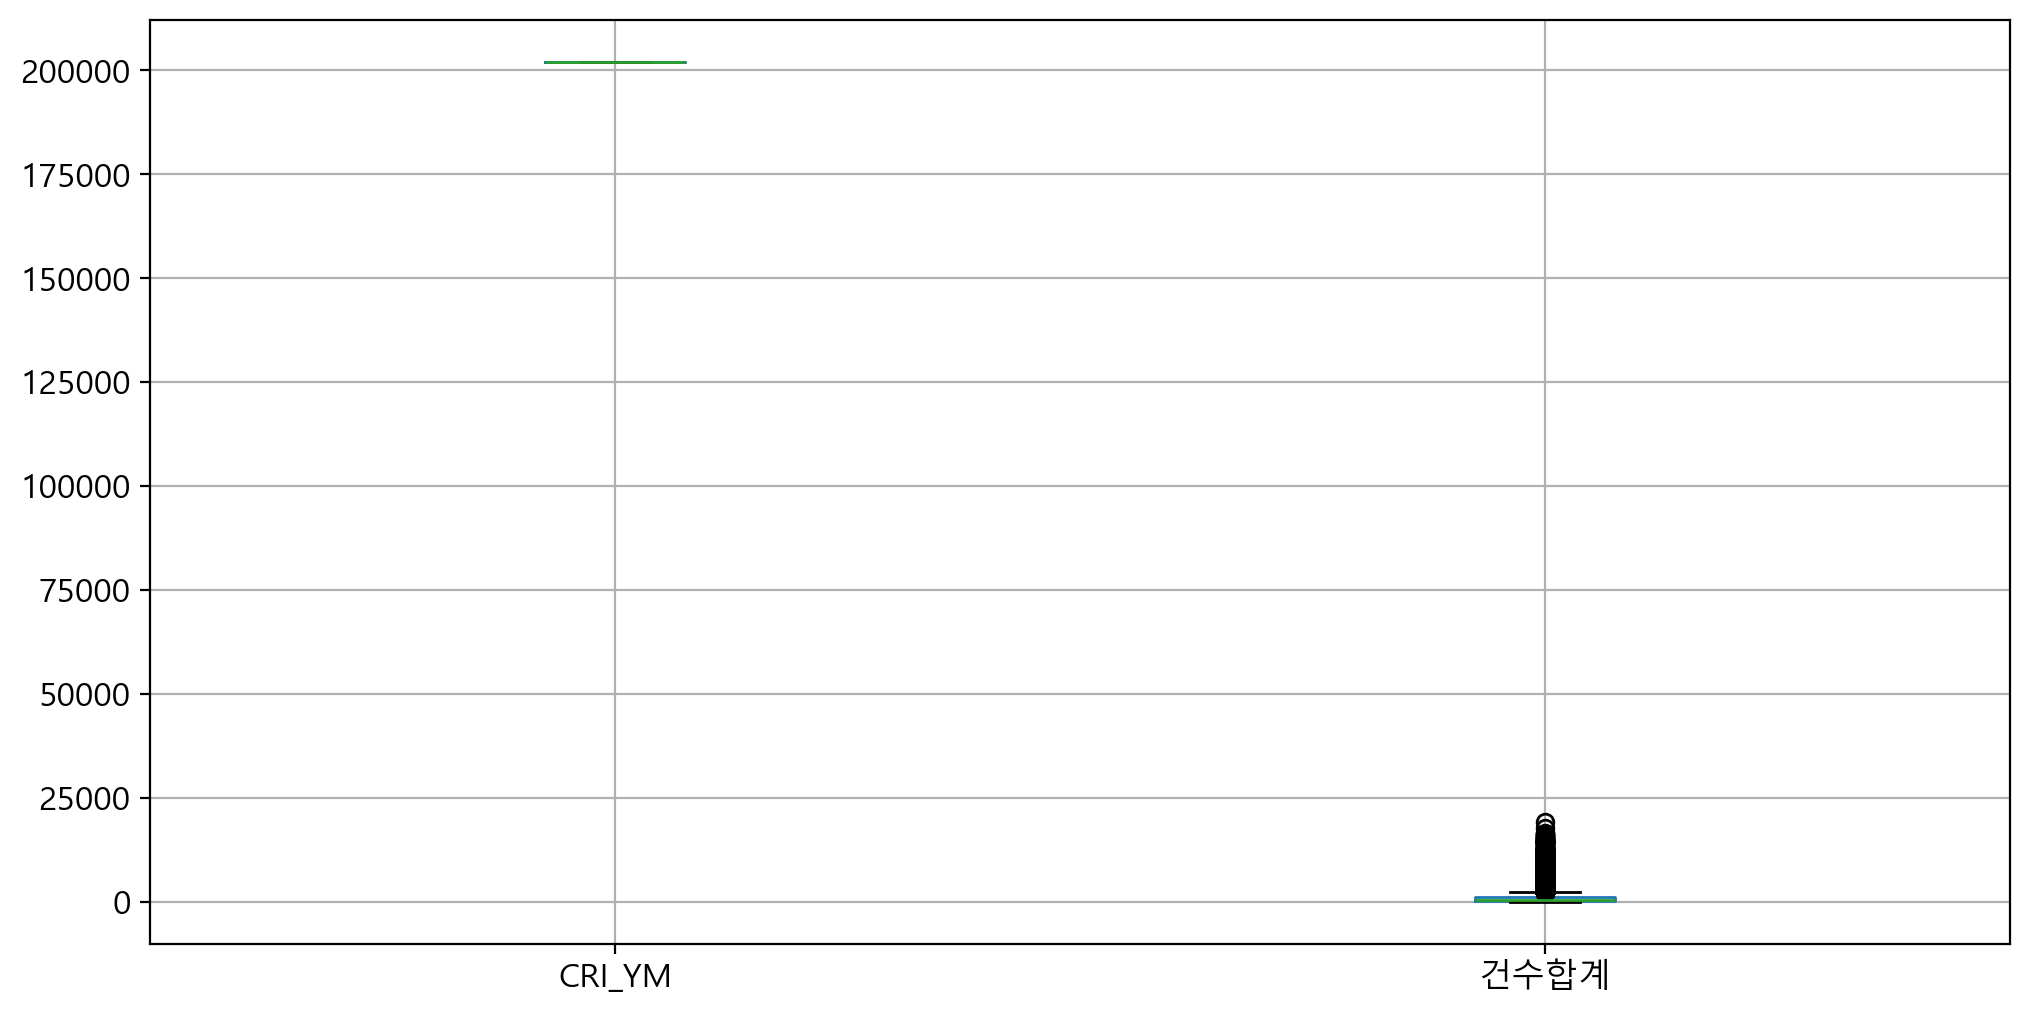

In [12]:
origin.boxplot()

In [7]:
df2 = df1[['요일_num','건수합계']].groupby(['요일_num']).agg('sum')
df2['요일'] = ['월','화','수','목','금','토','일']
df2.reset_index(inplace=True,drop=True)
df2.set_index('요일',inplace=True)
df2



,건수합계
요일,
월,48962
화,40722
수,42255
목,40975
금,37359
토,30706
일,39742


<Axes: xlabel='요일'>

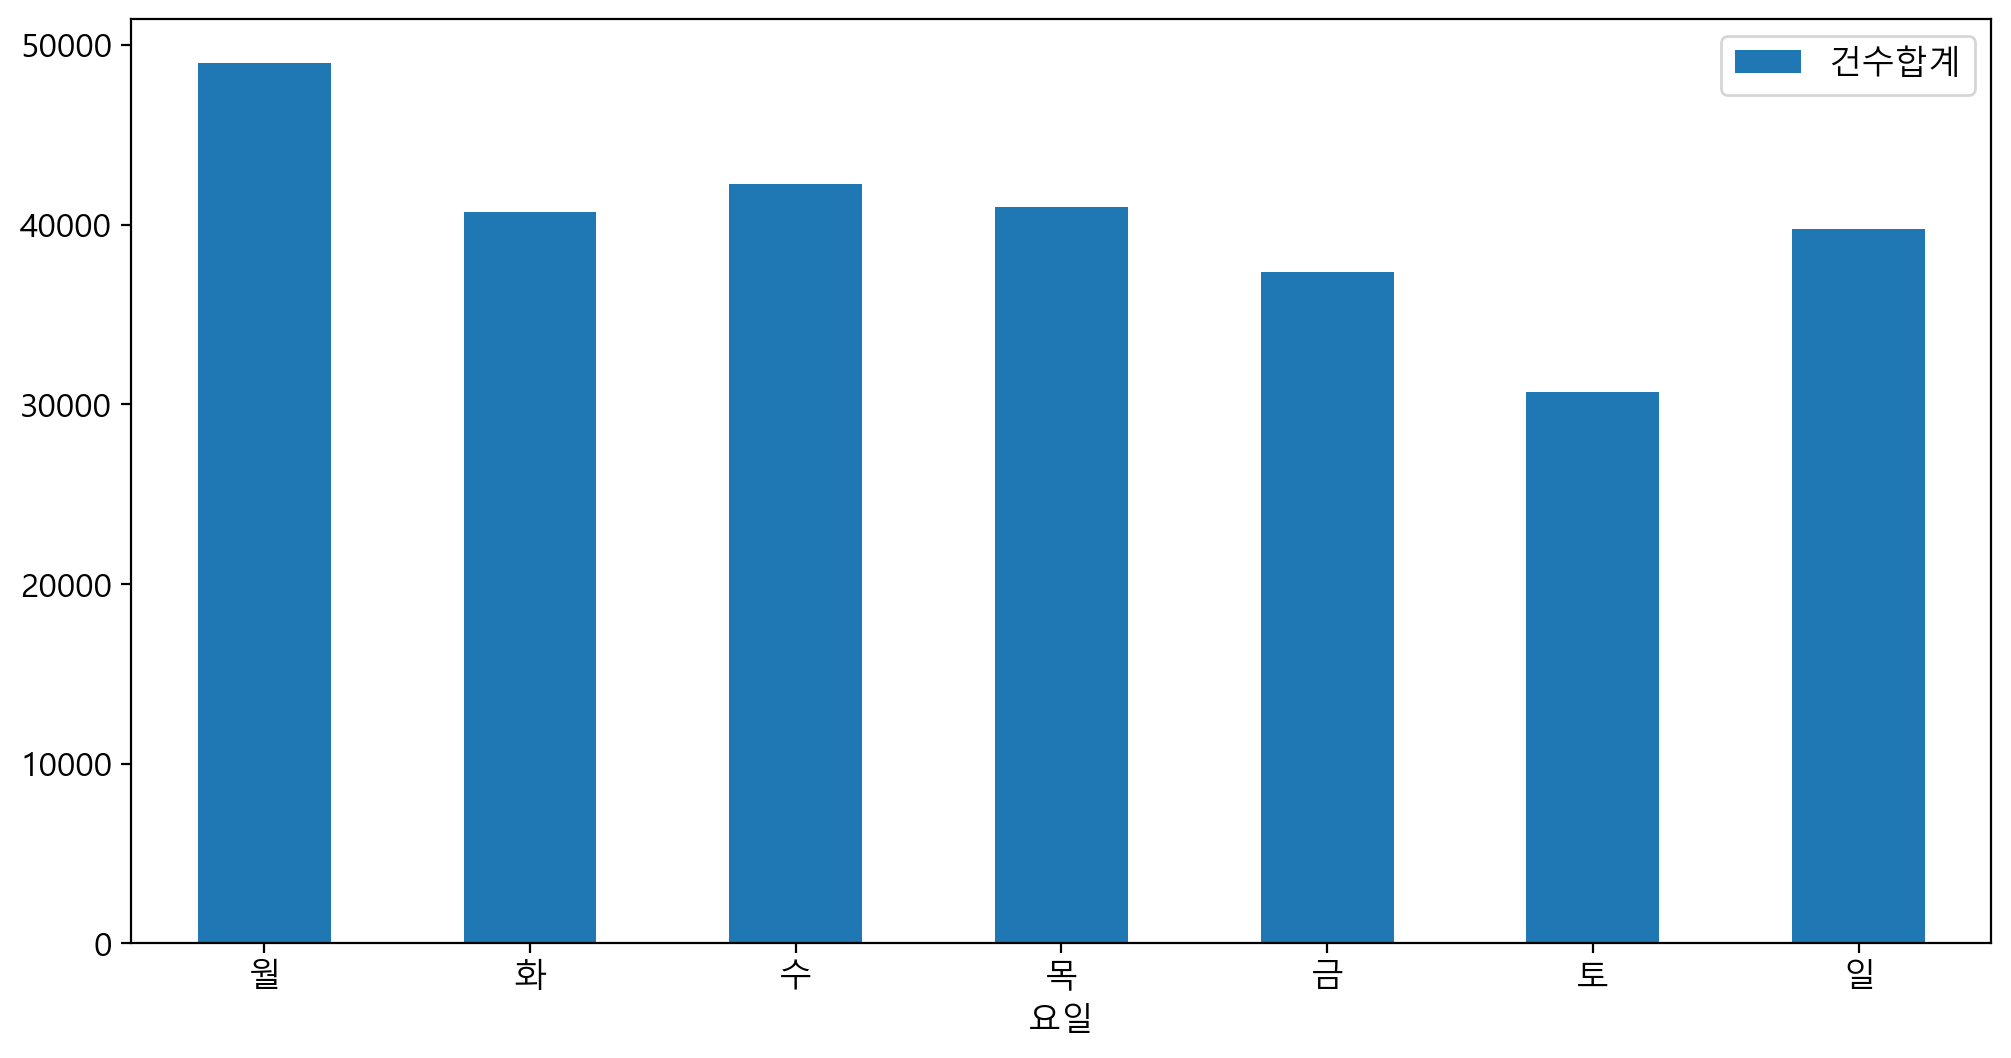

In [8]:
# 요일별로 분리
# => 각 요일별 시간대 분리
df2.plot(kind = 'bar', rot=0)


In [9]:
r1 = df1.query('요일_num == 1')
r2 = df1.query('요일_num == 2')
r3 = df1.query('요일_num == 3')
r4 = df1.query('요일_num == 4')
r5 = df1.query('요일_num == 5')
r6 = df1.query('요일_num == 6')
r7 = df1.query('요일_num == 7')
r1

,CRI_YM,TAG,평일휴일,요일,시간대,성별,연령대,건수합계,요일_num
208,202105,애완용품,평일,월,B.06-10시,M,C.4O대,270,1
216,201905,애완용품,평일,월,E.18-22시,M,A.2O대,62,1
323,201905,애완용품,평일,월,F.22-02시,F,A.2O대,253,1
343,201905,애완용품,평일,월,C.10-14시,F,C.4O대,367,1
382,201905,애완용품,휴일,월,E.18-22시,M,A.2O대,20,1
...,...,...,...,...,...,...,...,...,...
20890,201905,애완용품,평일,월,D.14-18시,F,B.3O대,442,1
20892,202105,애완용품,평일,월,B.06-10시,F,D.5O대,294,1
20898,202005,애완용품,평일,월,E.18-22시,M,E.60대이상,34,1
21133,202005,애완용품,평일,월,E.18-22시,F,C.4O대,594,1


In [10]:
r11 = r1[['시간대','건수합계']].groupby(['시간대']).agg('sum')
r12 = r2[['시간대','건수합계']].groupby(['시간대']).agg('sum')
r13 = r3[['시간대','건수합계']].groupby(['시간대']).agg('sum')
r14 = r4[['시간대','건수합계']].groupby(['시간대']).agg('sum')
r15 = r5[['시간대','건수합계']].groupby(['시간대']).agg('sum')
r16 = r6[['시간대','건수합계']].groupby(['시간대']).agg('sum')
r17 = r7[['시간대','건수합계']].groupby(['시간대']).agg('sum')
r11 

,건수합계
시간대,
A.02-06시,1644
B.06-10시,5493
C.10-14시,12126
D.14-18시,10607
E.18-22시,10042
F.22-02시,9050


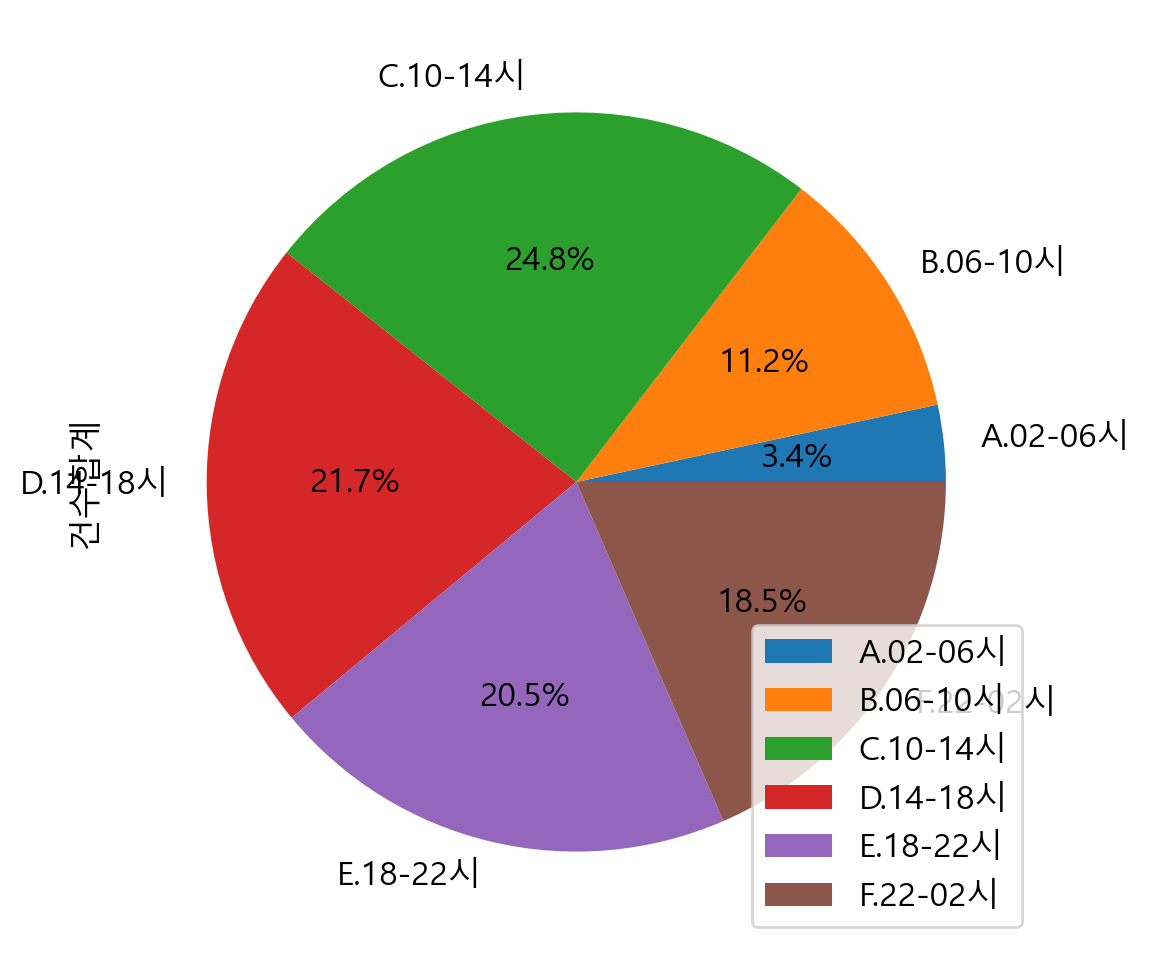

In [11]:
r11.plot(kind = 'pie',autopct='%0.1f%%',subplots=True)
plt.show()
plt.close()

# 요일별/시간대별 : 7개
# 성별/연령대
# 이미 광고하고있는곳에서 시간대를 축소시켜 광고비 절감

# 주제선정으로 목표를 좁히고 이후 진행할것